### Modelling

This notebook is dedicated to training the following model: DeepLabV3 with ResNet-34 Encoder. Additionally, its performace will be tested on Sentinel-2 based test set, Landsat test set & Boris flood test set

In [ ]:
pip install sentinelhub

In [ ]:
pip install segmentation_models_pytorch

In [ ]:
pip install albumentations

In [ ]:
pip install wandb

In [18]:
import os, sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import rasterio
import torchvision.transforms as T
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import importlib.util
import albumentations as A
from albumentations.pytorch import ToTensorV2
from pathlib import Path
import glob

### Preparing dataset

In [6]:
def load_module(name, path):
    path = Path(path).resolve()
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module

In [7]:
# testing that data import works

flood_dataset = load_module("flood_dataset", "scripts/data_model/flood_dataset.py")
FloodDataset = flood_dataset.FloodDataset
plot_sample = flood_dataset.plot_sample

train_transform = A.Compose([
    ToTensorV2()
])

train_dataset = FloodDataset("./Data/Split/train_split.json", transform=train_transform)
test_dataset = FloodDataset("./Data/Split/test_split.json", transform=train_transform)
boris_dataset = FloodDataset("./Data_Boris/Split/tile_patch_pairs.json", transform=train_transform)
landsat_dataset = FloodDataset("./Data_Landsat/Split/tile_patch_pairs.json", transform=train_transform)

print(f"Train Dataset: {len(train_dataset)}, Test Dataset: {len(test_dataset)}, Boris Dataset: {len(boris_dataset)}, Landsat Dataset: {len(landsat_dataset)}")

Train Dataset: 11900, Test Dataset: 2550, Boris Dataset: 1446, Landsat Dataset: 768


### Functions

In [8]:
training = load_module("training", "scripts/model_training/training.py")

#IMPORT TRAINING RELATED FUNCTIONS
train_model = training.train_model
test_model = training.test_model


model1 = load_module("model1", "scripts/models/deeplab.py")
model2 = load_module("model2", "scripts/models/deeplabresnet50.py")
model3 = load_module("model3", "scripts/models/unet.py")
model4 = load_module("model4", "scripts/models/deeplabresnet34.py")
model5 = load_module("model5", "scripts/models/unetresnet.py")

#IMPORT MODEL
DeepLabMobileNet = model1.DeepLabMobileNet

#IMPORT MODEL
DeepLabResNet = model2.DeepLabResNet

#IMPORT MODEL
UnetMobileNetV2 = model3.UnetMobileNetV2

#IMPORT MODEL
DeepLabResNet34 = model4.DeepLabResNet34

#IMPORT MODEL
UnetResNet = model5.UnetResNet

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /home/jovyan/.netrc
wandb: Currently logged in as: ovsvc (ovsvc-tu-wien) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [9]:
# Data Augmentation - simple

train_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])


# Data Augmentation - more advanced


train_transform_advanced = A.Compose([

    A.OneOf([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ], p=0.7),

    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.4, p=0.5),  # from articles
    A.RandomGamma(gamma_limit=(80, 150), p=0.4),  # gamma range ~[0.5, 1.5]
    A.RandomScale(scale_limit=0.1, p=0.3),  # simulate sensor resolution variation

    A.Normalize(),  # standardize inputs (use custom mean/std if needed)
    A.Resize(64, 64),
    ToTensorV2()
])



train_transform_soft = A.Compose([

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.1,  # reduced from 0.2
        contrast_limit=0.2,    # reduced from 0.4
        p=0.3
    ),

    A.RandomGamma(gamma_limit=(90, 120), p=0.2),  # narrower, realistic range

    # A slight noise addition can simulate atmospheric effects
    A.GaussNoise(p=0.2),

    A.Resize(64, 64),  # resizing before normalize to avoid interpolation on normalized data
    A.Normalize(),
    ToTensorV2()
])


train_transform_soft2 = A.Compose([

    A.OneOf([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ], p=0.7),
    A.Resize(64, 64), 
    A.Normalize(),
    ToTensorV2()
])


train_transform_tuned = A.Compose([
    
    A.OneOf([
        A.HorizontalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
    ], p=0.3),
    A.Resize(64, 64),      # preserve more spatial info than 64x64
    A.Normalize(),
    ToTensorV2()
])

### Models Experiments

#### UNetResNet34

In [11]:

config = {
    'model':  UnetResNet(num_classes=4, pretrained = True),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json",
    'model_save_dir': './models_resnet',
    'results_save_dir': './results_resnet',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 128,
    'learning_rate': 0.0001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 6,
    'fraction': 1,
    'val_frequency': 2,
    'debug_mode': True,
    'patience': 3,
    'model_name': "UNetResNet34",
    'subset_size': 3000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 0.9, 0.3, 0.3]
}

# Train the model

trainer = train_model(config)

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 3000
Validation dataset length: 2550
Test dataset length: 2550
Model: UnetResNet(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
 

Training with batch size: 128
Epoch 0/6:
--- Training epoch 0 ---


Train: 100%|██████████| 24/24 [08:04<00:00, 20.19s/it]


Epoch 0 Training Loss: 3491.1087703704834
Training Metrics: Focus (class 1) → IoU: 0.195, Dice: 0.327, Precision: 0.493, Recall: 0.244
Global → Acc: 0.264, mIoU: 0.120, Dice: 0.264, Prec: 0.264, Recall: 0.264
--- Validating epoch 0 ---


Evaluate: 100%|██████████| 20/20 [04:29<00:00, 13.47s/it]


...

Evaluate: 100%|██████████| 20/20 [04:38<00:00, 13.90s/it]


Epoch 4 Validation Loss: 1646.9631328582764
Validation Metrics: Focus (class 1) → IoU: 0.489, Dice: 0.657, Precision: 0.549, Recall: 0.817
Global → Acc: 0.869, mIoU: 0.414, Dice: 0.869, Prec: 0.869, Recall: 0.869
#### Best val_miou 0.41393905878067017 at epoch 4
#### Saving model to models_resnet
Model saved to models_resnet/unet_unet_resnet34_Unet resnet - 2best.pth
Epoch 5/6:
--- Training epoch 5 ---


Train: 100%|██████████| 24/24 [05:22<00:00, 13.45s/it]

Epoch 5 Training Loss: 1577.6794352531433
Training Metrics: Focus (class 1) → IoU: 0.636, Dice: 0.778, Precision: 0.657, Recall: 0.952
Global → Acc: 0.907, mIoU: 0.490, Dice: 0.907, Prec: 0.907, Recall: 0.907


epoch,▁▂▄▅▇█
train/acc,▁▅▇▇██
train/dice_1,▁▆▇███
train/iou_1,▁▆▇▇██
train/loss,█▅▄▂▁▁
train/miou,▁▄▆▆▇█
train/precision_1,▁▅▆▇▇█
train/recall_1,▁▆▇███
val/acc,▁▇█
val/dice_1,▁██
val/iou_1,▁██


In [27]:
test_loss, test_metric = test_model(config, trainer=trainer)

CUDA (GPU) is available.
Testing the model...


Model name... Unet resnet


Test: 100%|██████████| 20/20 [04:29<00:00, 13.46s/it]

Test Metrics: Focus (class 1) → IoU: 0.498, Dice: 0.665, Precision: 0.555, Recall: 0.829
Global → Acc: 0.897, mIoU: 0.525, Dice: 0.897, Prec: 0.897, Recall: 0.897


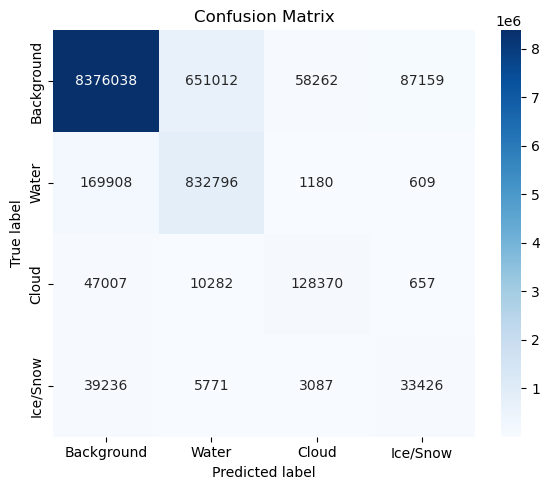

In [28]:
class_names = ["Background", "Water", "Cloud", "Ice/Snow"]
test_metric.plot_confusion_matrix(class_names=class_names)

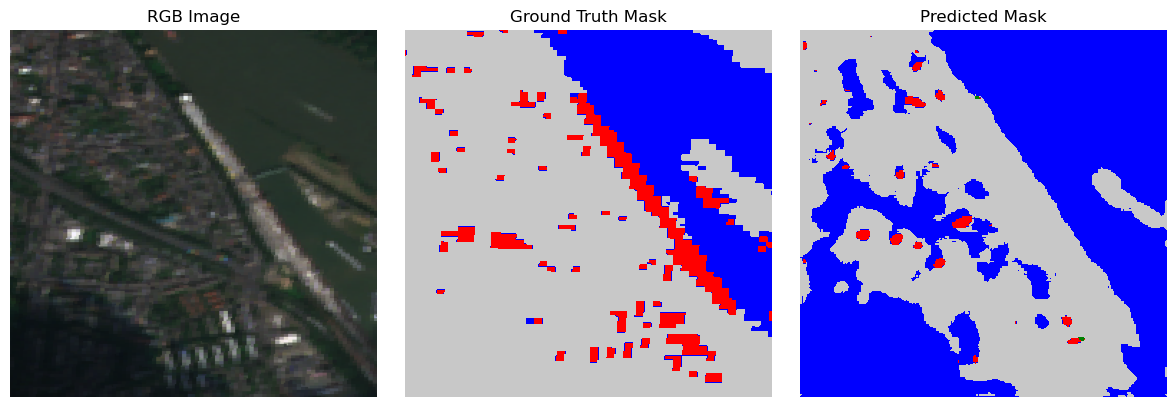

📊 Metrics for sample index 202
0: {'IoU': 0.5424686670303345, 'Dice': 0.7033771872520447, 'Precision': 0.8720512390136719, 'Recall': 0.5893783569335938}
1: {'IoU': 0.4353013038635254, 'Dice': 0.6065643429756165, 'Precision': 0.43690311908721924, 'Recall': 0.9916478991508484}
2: {'IoU': 0.07396504282951355, 'Dice': 0.13774199783802032, 'Precision': 0.5982142686843872, 'Recall': 0.07783155888319016}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [29]:
import torch
model = UnetResNet(num_classes=4)
model.load_state_dict(torch.load("./models_experiments_1/unet_unet_resnet34_Unet resnetbest.pth", map_location='cpu'))
model.to("cuda")  # or "cpu"

# Inspect
inspect_sample(test_dataset, 
               model2, 
               test_metric2, 
               idx=202, device='cuda')

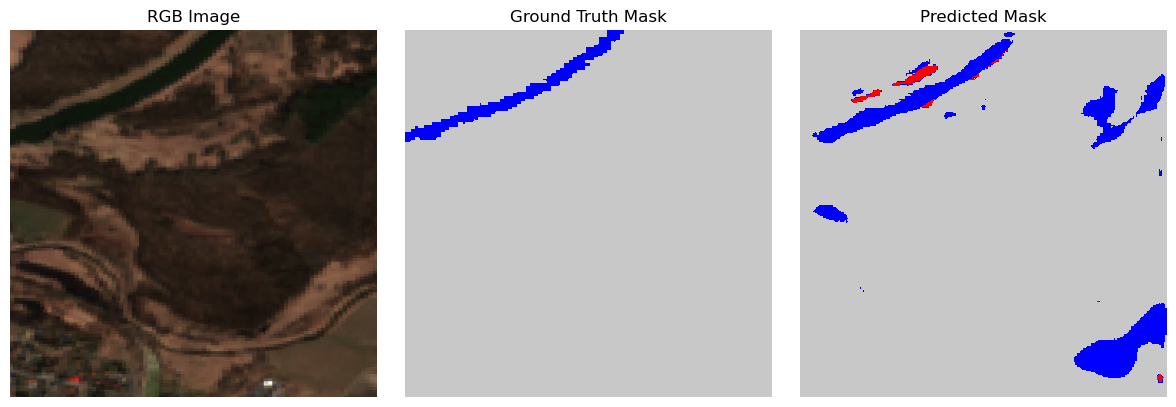

📊 Metrics for sample index 205
0: {'IoU': 0.9378323554992676, 'Dice': 0.9679189920425415, 'Precision': 0.9929581880569458, 'Recall': 0.9441114664077759}
1: {'IoU': 0.2183932363986969, 'Dice': 0.358493834733963, 'Precision': 0.2401767075061798, 'Recall': 0.706566333770752}
2: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [30]:
import torch
model = UnetResNet(num_classes=4)
model.load_state_dict(torch.load("./models_experiments_1/unet_unet_resnet34_Unet resnetbest.pth", map_location='cpu'))
model.to("cuda")  # or "cpu"

# Inspect
inspect_sample(test_dataset, 
               model2, 
               test_metric2, 
               idx=205, device='cuda')

#### UNetResNet50

In [10]:
config2 = {
    'model':  UnetResNet(num_classes=4, backbone="resnet50", pretrained = True),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json",
    'model_save_dir': './models_resnet',
    'results_save_dir': './results_resnet',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 128,
    'learning_rate': 0.001, 
    'scheduler_gamma': 0.9,
    'epochs': 4,
    'fraction': 1,
    'val_frequency': 2,
    'debug_mode': True,
    'patience': 3,
    'model_name': "UNetResNet50",
    'subset_size': 3000, 
    'class_weights': [0.1, 0.9, 0.3, 0.3]
}

# Train the model

trainer2 = train_model(config2)

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 3000
Validation dataset length: 2550
Test dataset length: 2550
Model: UnetResNet(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1

ERROR: ld.so: object '/opt/conda/lib/libmkl_def.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_avx2.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_core.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_intel_lp64.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_intel_thread.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.


Training with batch size: 128
Epoch 0/4:
--- Training epoch 0 ---


Train: 100%|██████████| 24/24 [05:38<00:00, 14.11s/it]


Epoch 0 Training Loss: 2096.540019273758
Training Metrics: Focus (class 1) → IoU: 0.278, Dice: 0.435, Precision: 0.296, Recall: 0.820
Global → Acc: 0.749, mIoU: 0.310, Dice: 0.749, Prec: 0.749, Recall: 0.749
--- Validating epoch 0 ---


...

Evaluate: 100%|██████████| 20/20 [04:34<00:00, 13.70s/it]


Epoch 2 Validation Loss: 1122.7349388599396
Validation Metrics: Focus (class 1) → IoU: 0.557, Dice: 0.716, Precision: 0.670, Recall: 0.769
Global → Acc: 0.926, mIoU: 0.556, Dice: 0.926, Prec: 0.926, Recall: 0.926
#### Best val_miou 0.556372880935669 at epoch 2
#### Saving model to models_resnet
Model saved to models_resnet/unet_unet_resnet50_Unet resnet 50best.pth
Epoch 3/4:
--- Training epoch 3 ---


Train: 100%|██████████| 24/24 [05:39<00:00, 14.13s/it]

Epoch 3 Training Loss: 1055.5944528579712
Training Metrics: Focus (class 1) → IoU: 0.588, Dice: 0.740, Precision: 0.642, Recall: 0.875
Global → Acc: 0.928, mIoU: 0.595, Dice: 0.928, Prec: 0.928, Recall: 0.928


epoch,▁▃▆█
train/acc,▁▇▇█
train/dice_1,▁▇▇█
train/iou_1,▁▆▆█
train/loss,█▃▂▁
train/miou,▁▅▆█
train/precision_1,▁▆▆█
train/recall_1,▁▅▇█
val/acc,▁█
val/dice_1,▁█
val/iou_1,▁█


#### UnetMobileNetV2

In [11]:
config3 = {
    'model':  UnetMobileNetV2(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json",
    'model_save_dir': './models_experiments_1',
    'results_save_dir': './results_experiments_1',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 128, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    'scheduler_gamma': 0.9,
    'epochs': 4,
    'fraction': 1,
    'val_frequency': 2,
    'debug_mode': True,
    'patience': 3,
    'model_name': "UnetMobileNetV2 + 128x128",
    'subset_size': 3000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 0.9, 0.3, 0.3]
}

# Train the model

#trainer4 = train_model(config4)

In [12]:
test_loss3, test_metric3 = test_model(config3, model_name = "_unet_mobilenetv2_0.9 + 128 batches + 3k + higher resolbest")

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 3000
Validation dataset length: 2550
Test dataset length: 2550
Model: UnetMobileNetV2(
  (model): Unet(
    (encoder): MobileNetV2Encoder(
      (features): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): InvertedResidual(
          (conv): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): ReLU6(inplace=True)
            )
            (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (2): BatchNorm2d(16, eps=1e-05, momentum=

ERROR: ld.so: object '/opt/conda/lib/libmkl_def.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_avx2.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_core.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_intel_lp64.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_intel_thread.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.


Testing the model...


Model name... 0.9 + 128 batches + 3k + higher resol


Test: 100%|██████████| 20/20 [19:37<00:00, 58.89s/it]

Test Metrics: Focus (class 1) → IoU: 0.586, Dice: 0.739, Precision: 0.681, Recall: 0.809
Global → Acc: 0.923, mIoU: 0.557, Dice: 0.923, Prec: 0.923, Recall: 0.923


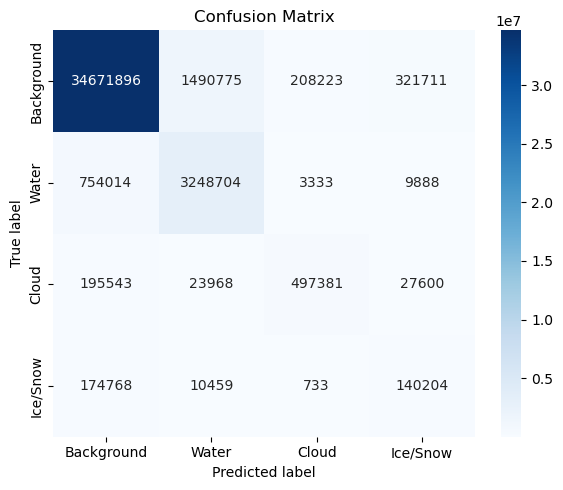

In [14]:
class_names = ["Background", "Water", "Cloud", "Ice/Snow"]
test_metric4.plot_confusion_matrix(class_names=class_names)

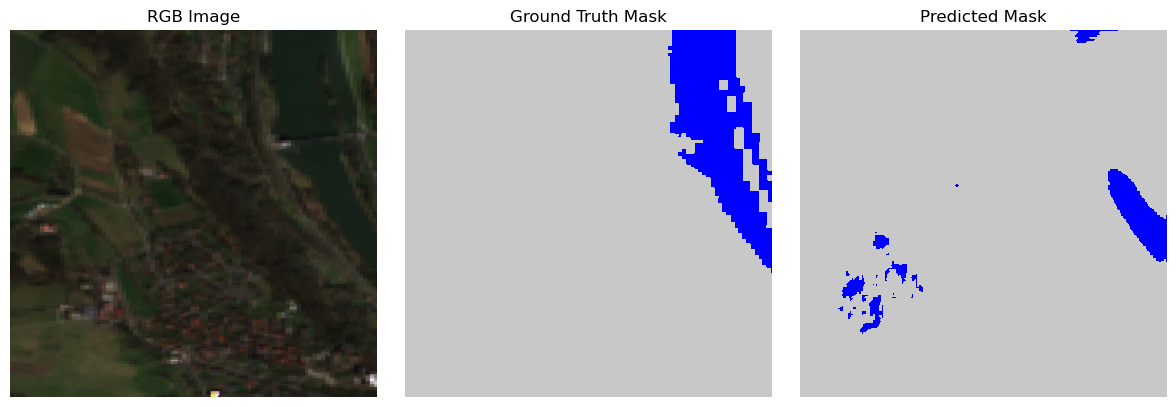

📊 Metrics for sample index 237
0: {'IoU': 0.9132161736488342, 'Dice': 0.9546398520469666, 'Precision': 0.9238370060920715, 'Recall': 0.9875676035881042}
1: {'IoU': 0.19412700831890106, 'Dice': 0.32513627409935, 'Precision': 0.6451923251152039, 'Recall': 0.21732793748378754}
2: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [37]:
import torch
model4 = UnetMobileNetV2(num_classes=4)
model4.load_state_dict(torch.load("./models_experiments_1/_unet_mobilenetv2_0.9 + 128 batches + 3k + higher resolbest.pth", map_location='cpu'))
model4.to("cuda") 

# Inspect
inspect_sample(test_dataset, 
               model4, 
               test_metric4, 
               idx=237, device='cuda')

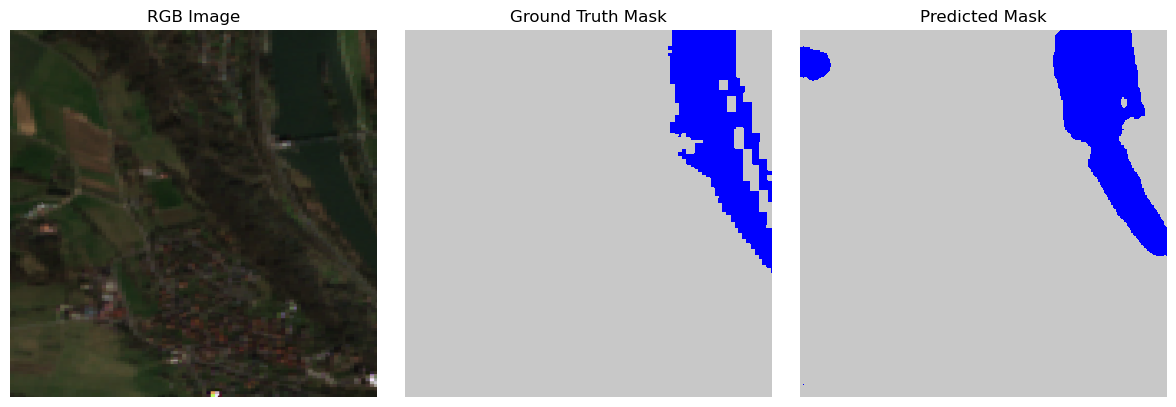

📊 Metrics for sample index 237
0: {'IoU': 0.9634453654289246, 'Dice': 0.981382429599762, 'Precision': 0.9846526980400085, 'Recall': 0.9781337976455688}
1: {'IoU': 0.7052053809165955, 'Dice': 0.8271207809448242, 'Precision': 0.8023751378059387, 'Recall': 0.8534412980079651}
2: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}
3: {'IoU': 0.0, 'Dice': 0.0, 'Precision': 0.0, 'Recall': 0.0}


In [38]:
# Same moedl as above but trained on more data

model5 = UnetMobileNetV2(num_classes=4)
model5.load_state_dict(torch.load("./models_experiments_1/unet_mobilenetv3_0.9 + 128 batches + 6kbest.pth", map_location='cpu'))
model5.to("cuda") 

# Inspect
inspect_sample(test_dataset, 
               model5, 
               test_metric5, 
               idx=237, device='cuda')

### Deeplab with better resolution

In [13]:
train_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])


config4 = {
    'model':  DeepLabResNet34(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json",
    'model_save_dir': './models_deeplab',
    'results_save_dir': './results_deeplab',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 128, # maybe increase batch size
    'learning_rate': 0.001, # maybe replace with 0.01 for faster learning + increase patience in lr
    #'scheduler_gamma': 0.9,
    'epochs': 20,
    'fraction': 1,
    'val_frequency': 3,
    'debug_mode': True,
    'patience': 3,
    'model_name': "DeepLab+ResNet34",
    'subset_size': 8000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 0.9, 0.3, 0.3]
}

# Train the model

trainer4 = train_model(config)


CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 8000
Validation dataset length: 2550
Test dataset length: 2550
Model: DeepLabResNet34(
  (model): DeepLabV3(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

Training with batch size: 128
Epoch 0/20:
--- Training epoch 0 ---


Train: 100%|██████████| 63/63 [58:46<00:00, 55.98s/it]

Epoch 0 Training Loss: 4246.450180053711
Training Metrics: Focus (class 1) → IoU: 0.384, Dice: 0.554, Precision: 0.419, Recall: 0.818
Global → Acc: 0.838, mIoU: 0.396, Dice: 0.838, Prec: 0.838, Recall: 0.838


--- Validating epoch 0 ---


...

Epoch 9 Training Loss: 1693.8534870147705
Training Metrics: Focus (class 1) → IoU: 0.765, Dice: 0.867, Precision: 0.802, Recall: 0.944
Global → Acc: 0.961, mIoU: 0.719, Dice: 0.961, Prec: 0.961, Recall: 0.961
--- Validating epoch 9 ---


Evaluate: 100%|██████████| 20/20 [19:35<00:00, 58.78s/it]


Epoch 9 Validation Loss: 676.3785790205002
Validation Metrics: Focus (class 1) → IoU: 0.744, Dice: 0.853, Precision: 0.809, Recall: 0.903
Global → Acc: 0.958, mIoU: 0.682, Dice: 0.958, Prec: 0.958, Recall: 0.958
Early stopping counter: 1/3
Epoch 10/20:
--- Training epoch 10 ---


Train:  14%|█▍        | 9/63 [09:36<57:41, 64.10s/it]  


KeyboardInterrupt: 

### Evaluation

In [11]:
evaluation = load_module("evaluation", "scripts/model_training/evaluation.py")

get_patch_grid = evaluation.get_patch_grid
stitch_with_uncertainty = evaluation.stitch_with_uncertainty
visualize_uncertainty_minimal = evaluation.visualize_uncertainty_minimal

evaluate_fixed_gt_with_confidence_thresholds = evaluation.evaluate_fixed_gt_with_confidence_thresholds
plot_metrics_vs_threshold = evaluation.plot_metrics_vs_threshold
plot_prediction_masks_by_threshold = evaluation.plot_prediction_masks_by_threshold

#### Boris Sentinel set evaluation

In [12]:
#test on boris set

train_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])


config4 = {
    'model':  DeepLabResNet34(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data_Boris/Split/tile_patch_pairs.json", # use Boris data for tests
    'model_save_dir': './models_deeplab',
    'results_save_dir': './results_deeplab',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 128, 
    'learning_rate': 0.001, 
    'epochs': 20,
    'fraction': 1,
    'val_frequency': 3,
    'debug_mode': True,
    'patience': 3,
    'model_name': "DeepLab+ResNet34",
    'subset_size': 8000, 
    'class_weights': [0.1, 0.9, 0.3, 0.3]
}

test_loss5, test_metric5 = test_model(config4, model_name = "deeplabv3_resnet34_model_DeepLab+ResNet34best" )

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 8000
Validation dataset length: 2550
Test dataset length: 1446
Model: DeepLabResNet34(
  (model): DeepLabV3(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

ERROR: ld.so: object '/opt/conda/lib/libmkl_def.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_avx2.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_core.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_intel_lp64.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.
ERROR: ld.so: object '/opt/conda/lib/libmkl_intel_thread.so' from LD_PRELOAD cannot be preloaded (cannot open shared object file): ignored.


Testing the model...


Model name... DeepLab+ResNet34


Test: 100%|██████████| 12/12 [10:37<00:00, 53.10s/it]

Test Metrics: Focus (class 1) → IoU: 0.602, Dice: 0.751, Precision: 0.760, Recall: 0.743
Global → Acc: 0.980, mIoU: 0.643, Dice: 0.980, Prec: 0.980, Recall: 0.980


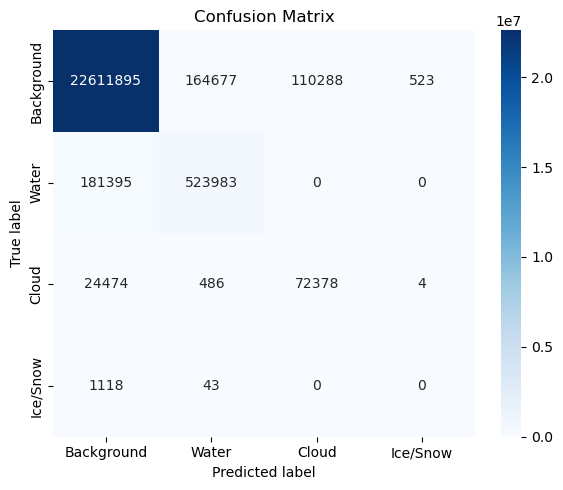

In [13]:
class_names = ["Background", "Water", "Cloud", "Ice/Snow"]
test_metric5.plot_confusion_matrix(class_names=class_names)

In [16]:
#test set
model4 = DeepLabResNet34(num_classes=4)
model4.load_state_dict(torch.load("./models_deeplab/deeplabv3_resnet34_model_DeepLab+ResNet34best.pth", map_location='cpu'))
model4.to("cuda")  # or "cpu"

DeepLabResNet34(
  (model): DeepLabV3(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (

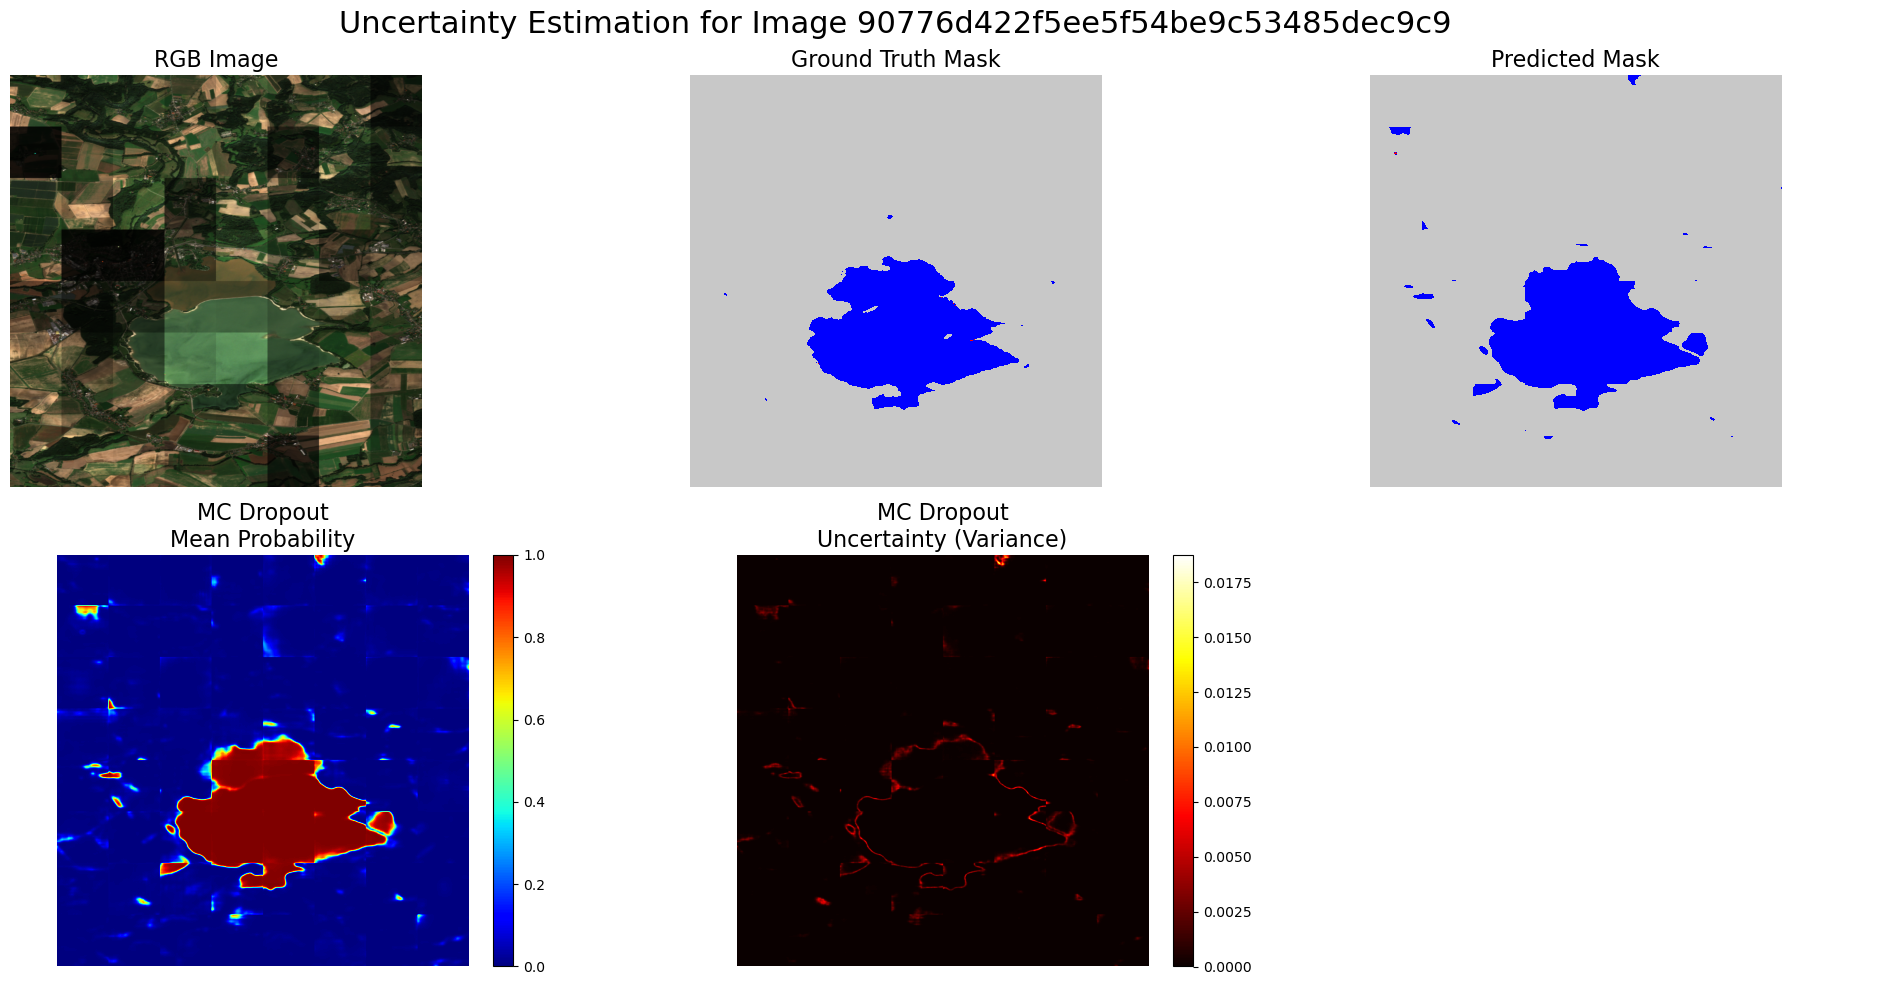

In [15]:
import glob 

image_dir = "./Data_Boris/OK/90776d422f5ee5f54be9c53485dec9c9" 
perm_water_path = "./Permanent_Water/Permanent_Water_Mask2-0000000000-0000000000.tif"


rgb_paths = sorted(glob.glob(os.path.join(image_dir, "rgb_nir_*.tif")))
grid = get_patch_grid(rgb_paths)

stitched_outputs = stitch_with_uncertainty(
    grid=grid,
    model=model4,
    perm_water_path=perm_water_path,
    threshold=0.5,
    device="cuda",
    n_iter=30
)

rgb_stitched, gt_stitched, pred_stitched, mc_mean_stitched, mc_var_stitched = stitched_outputs

visualize_uncertainty_minimal(
    rgb_img=rgb_stitched,
    gt_mask=gt_stitched,
    pred_mask=pred_stitched,
    mc_water_prob=mc_mean_stitched,
    uncertainty_map=mc_var_stitched,
    class_colors=["#c8c8c8", "blue", "red"],
    title="Uncertainty Estimation for Image 90776d422f5ee5f54be9c53485dec9c9"
)


#### Boris landsat set evaluation

In [19]:
train_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])


config4 = {
    'model':  DeepLabResNet34(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data_Landsat/Split/tile_patch_pairs.json",
    'model_save_dir': './models_deeplab',
    'results_save_dir': './results_deeplab',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 128, 
    'learning_rate': 0.001,
    'epochs': 20,
    'fraction': 1,
    'val_frequency': 3,
    'debug_mode': True,
    'patience': 3,
    'model_name': "DeepLab+ResNet34",
    'subset_size': 8000, # test everything on 1k - or  but 3.0000
    'class_weights': [0.1, 0.9, 0.3, 0.3]
}

In [20]:
#test on boris set
test_loss7, test_metric7 = test_model(config4, model_name = "deeplabv3_resnet34_model_DeepLab+ResNet34best" )

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 8000
Validation dataset length: 2550
Test dataset length: 768
Model: DeepLabResNet34(
  (model): DeepLabV3(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

test/acc,▁
test/dice_1,▁
test/iou_1,▁
test/loss,▁
test/miou,▁
test/precision_1,▁
test/recall_1,▁
test/acc,0.95841
test/dice_1,0.86739
test/iou_1,0.76583
test/loss,0.26507


Testing the model...


Model name... DeepLab+ResNet34


Test: 100%|██████████| 6/6 [05:28<00:00, 54.75s/it]

Test Metrics: Focus (class 1) → IoU: 0.021, Dice: 0.042, Precision: 0.024, Recall: 0.161
Global → Acc: 0.835, mIoU: 0.505, Dice: 0.835, Prec: 0.835, Recall: 0.835


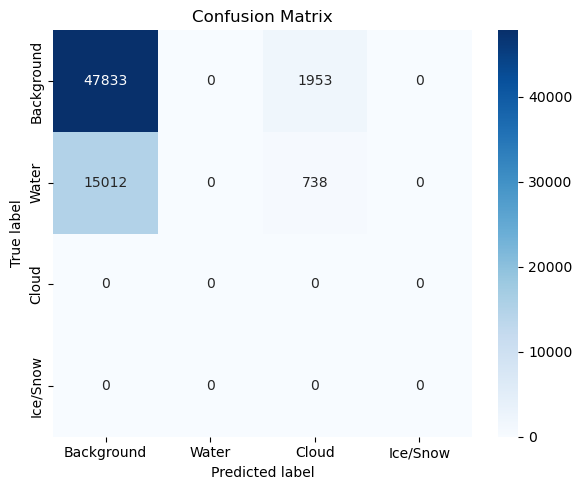

In [26]:
class_names = ["Background", "Water", "Cloud", "Ice/Snow"]
test_metric7.plot_confusion_matrix(class_names=class_names)

In [23]:
#test set
model4 = DeepLabResNet34(num_classes=4)
model4.load_state_dict(torch.load("./models_deeplab/deeplabv3_resnet34_model_DeepLab+ResNet34best.pth", map_location='cpu'))
model4.to("cuda")  # or "cpu"

DeepLabResNet34(
  (model): DeepLabV3(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (

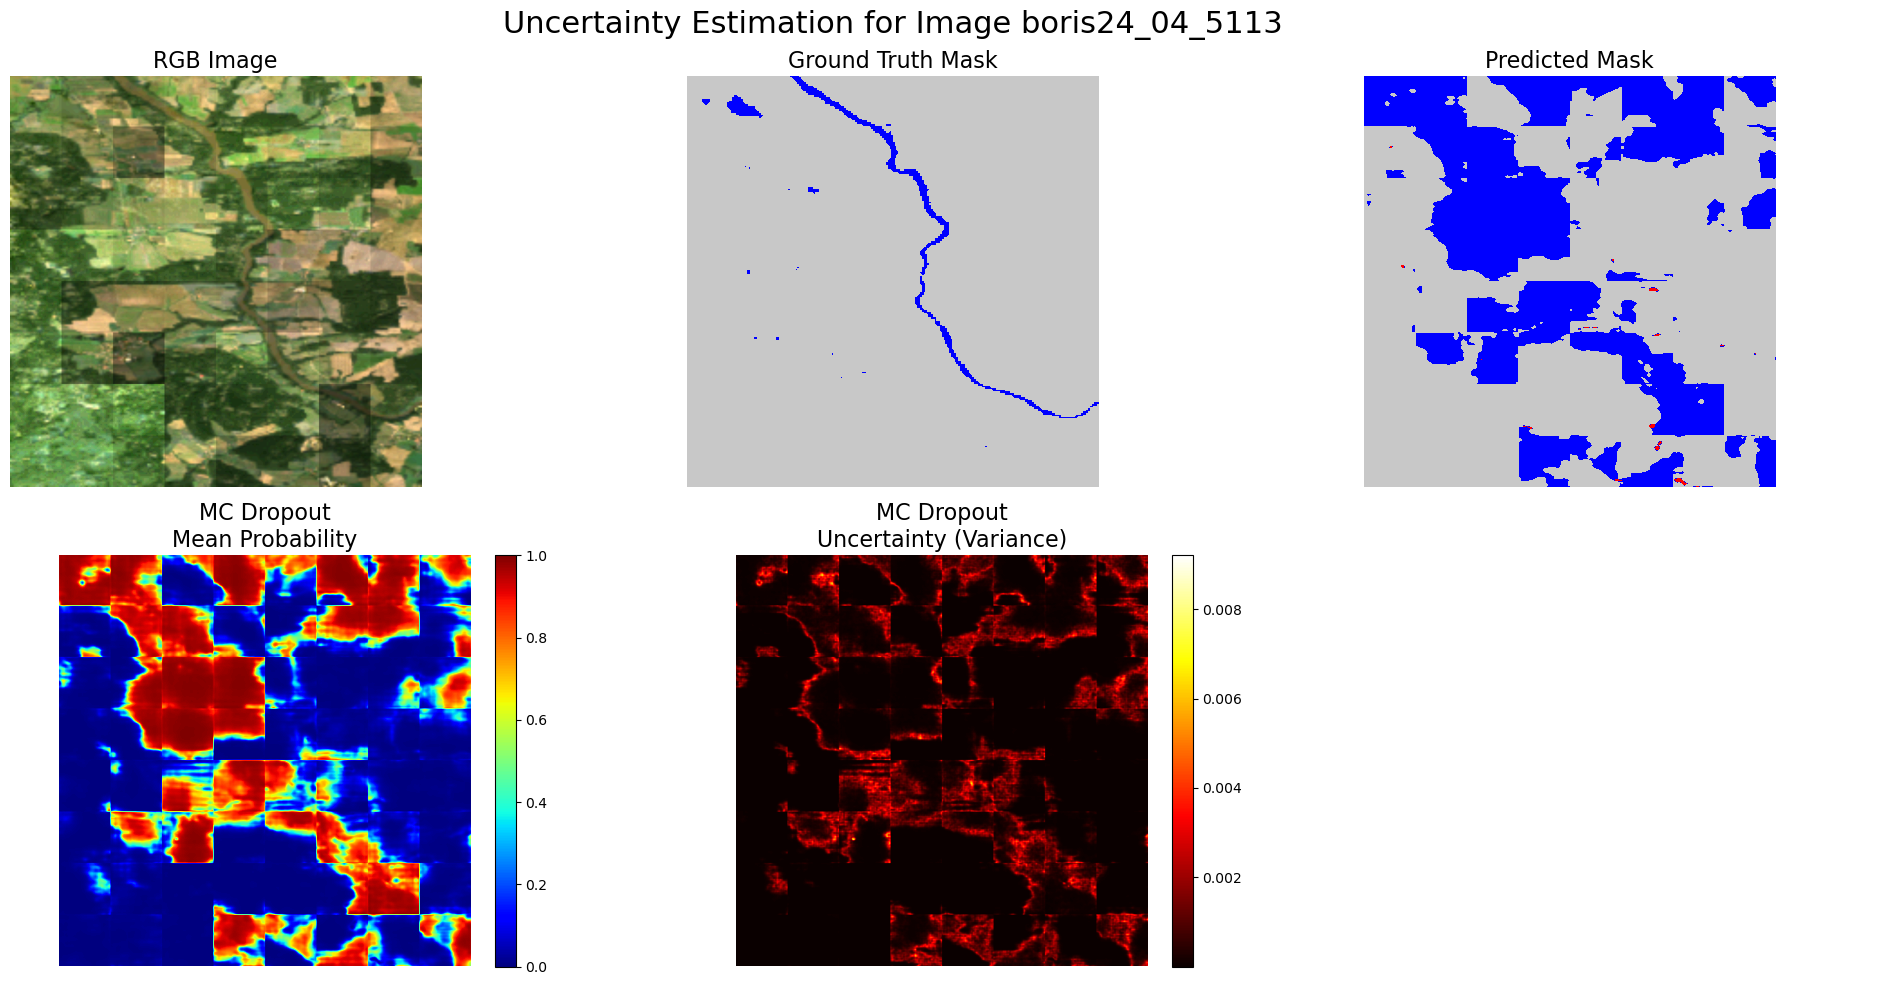

In [16]:
import glob
import os

image_dir = "./Data_Landsat/OK/boris24_04_5113" 
perm_water_path = "./Permanent_Water/Permanent_Water_Mask2-0000000000-0000000000.tif"


rgb_paths = sorted(glob.glob(os.path.join(image_dir, "rgb_nir_*.tif")))
grid = get_patch_grid(rgb_paths)

stitched_outputs = stitch_with_uncertainty(
    grid=grid,
    model=model4,
    perm_water_path=perm_water_path,
    threshold=0.5,
    device="cuda",
    n_iter=30
)

rgb_stitched, gt_stitched, pred_stitched, mc_mean_stitched, mc_var_stitched = stitched_outputs

visualize_uncertainty_minimal(
    rgb_img=rgb_stitched,
    gt_mask=gt_stitched,
    pred_mask=pred_stitched,
    mc_water_prob=mc_mean_stitched,
    uncertainty_map=mc_var_stitched,
    class_colors=["#c8c8c8", "blue", "red"],
    title="Uncertainty Estimation for Image boris24_04_5113"
)


#### Sentinel Test set evaluation

In [15]:
#test on test set

train_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])

test_transform = A.Compose([
    A.Resize(128, 128),
    ToTensorV2()
])


config4 = {
    'model':  DeepLabResNet34(num_classes=4),
    'val_split': "./Data/Split/val_split.json",
    'train_split':"./Data/Split/train_split.json",
    'test_split':"./Data/Split/test_split.json", # use test set data for tests
    'model_save_dir': './models_deeplab',
    'results_save_dir': './results_deeplab',
    'train_transform': train_transform,
    'val_transform': val_transform,
    'test_transform': test_transform,
    'batch_size': 128, 
    'learning_rate': 0.001,
    'epochs': 20,
    'fraction': 1,
    'val_frequency': 3,
    'debug_mode': True,
    'patience': 3,
    'model_name': "DeepLab+ResNet34",
    'subset_size': 8000,
    'class_weights': [0.1, 0.9, 0.3, 0.3]
}

test_loss6, test_metric6 = test_model(config4, model_name = "deeplabv3_resnet34_model_DeepLab+ResNet34best" )

CUDA (GPU) is available.
Preprocessing dataset...
Train dataset length: 8000
Validation dataset length: 2550
Test dataset length: 2550
Model: DeepLabResNet34(
  (model): DeepLabV3(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
 

test/acc,▁
test/dice_1,▁
test/iou_1,▁
test/loss,▁
test/miou,▁
test/precision_1,▁
test/recall_1,▁
test/acc,0.97961
test/dice_1,0.75146
test/iou_1,0.60188
test/loss,0.30466


Testing the model...


Model name... DeepLab+ResNet34


Test: 100%|██████████| 20/20 [18:15<00:00, 54.76s/it]

Test Metrics: Focus (class 1) → IoU: 0.766, Dice: 0.867, Precision: 0.839, Recall: 0.898
Global → Acc: 0.958, mIoU: 0.686, Dice: 0.958, Prec: 0.958, Recall: 0.958


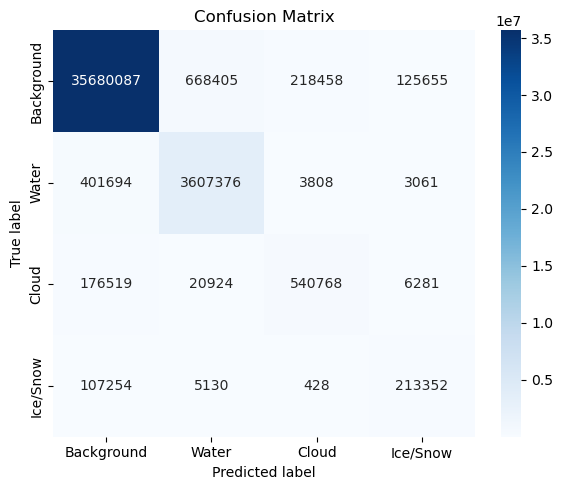

In [16]:
#test set

class_names = ["Background", "Water", "Cloud", "Ice/Snow"]
test_metric6.plot_confusion_matrix(class_names=class_names)

In [17]:
#test set
model6 = DeepLabResNet34(num_classes=4)
model6.load_state_dict(torch.load("./models_deeplab/deeplabv3_resnet34_model_DeepLab+ResNet34best.pth", map_location='cpu'))
model6.to("cuda")  # or "cpu"

DeepLabResNet34(
  (model): DeepLabV3(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (

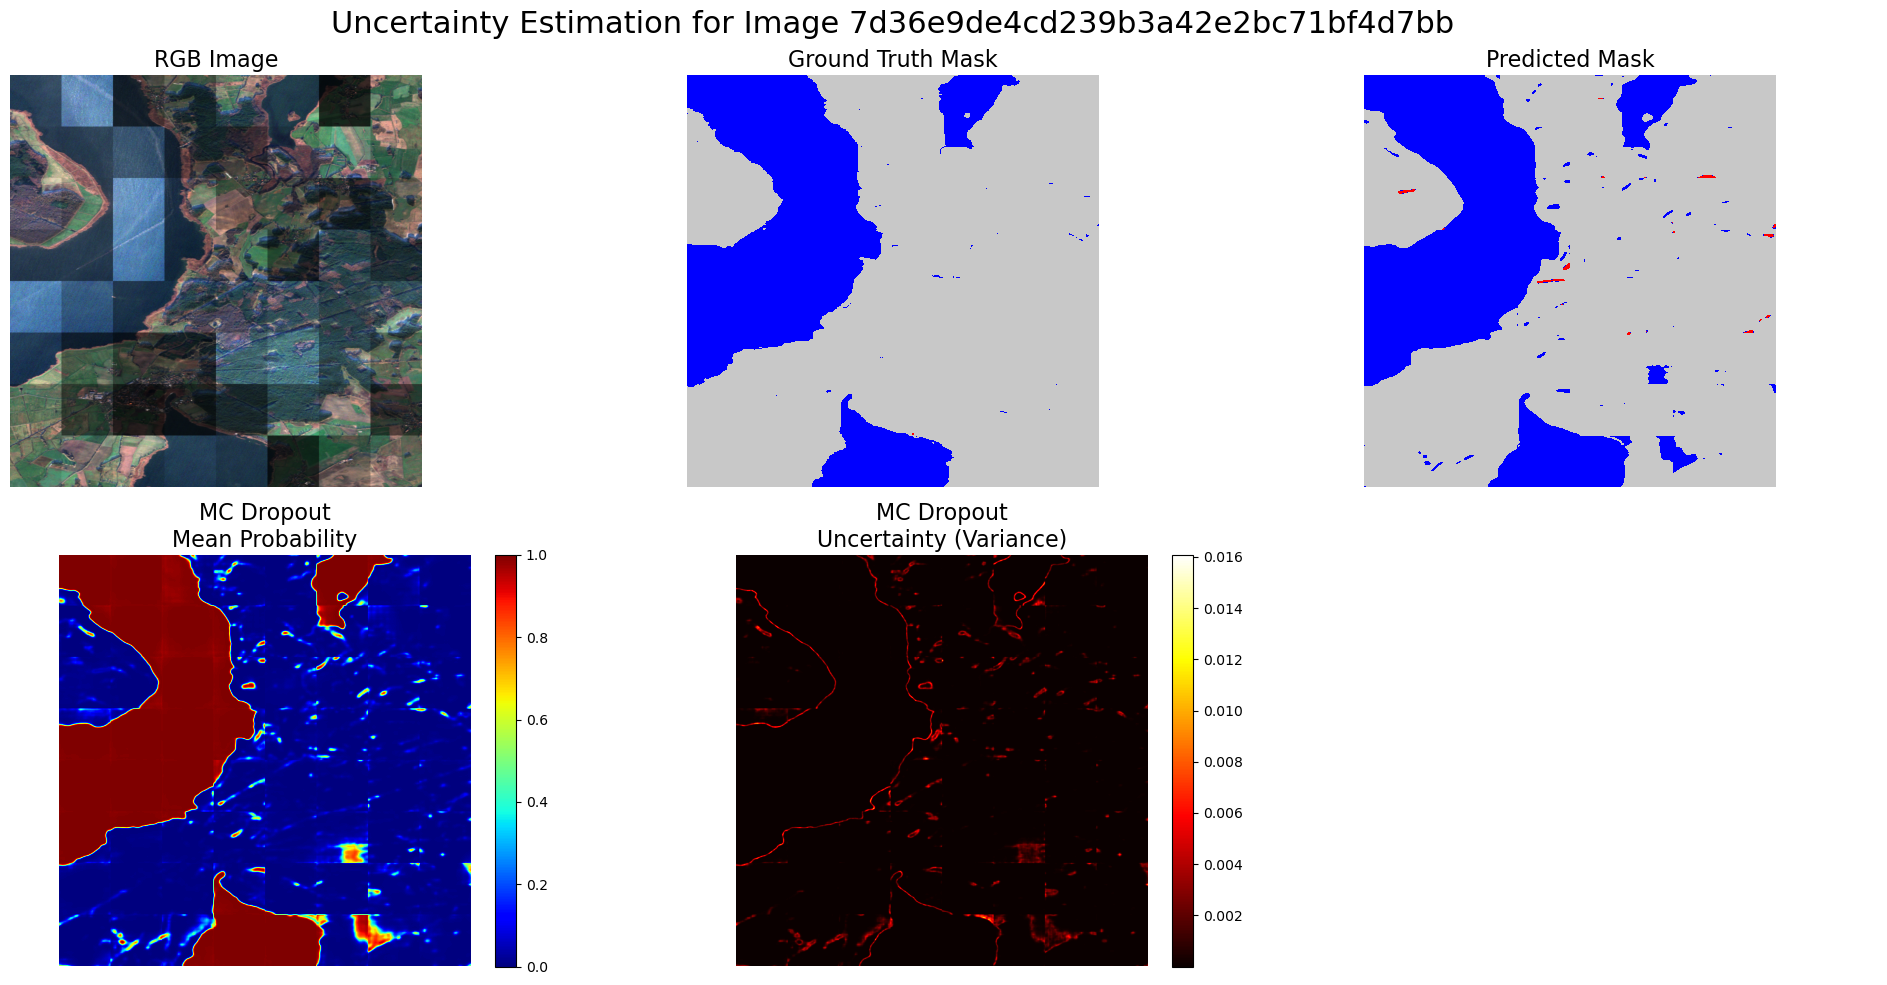

In [19]:
image_dir = "./Data/data_Q4_2024_raw/OK/7d36e9de4cd239b3a42e2bc71bf4d7bb"
perm_water_path = "./Permanent_Water/Permanent_Water_Mask2-0000000000-0000000000.tif"

rgb_paths = sorted(glob.glob(os.path.join(image_dir, "rgb_nir_*.tif")))
grid = get_patch_grid(rgb_paths)

stitched_outputs = stitch_with_uncertainty(
    grid=grid,
    model=model6,
    perm_water_path=perm_water_path,
    threshold=0.5,
    device="cuda",
    n_iter=30
)


rgb_stitched, gt_stitched, pred_stitched, mc_mean_stitched, mc_var_stitched = stitched_outputs

visualize_uncertainty_minimal(
    rgb_img=rgb_stitched,
    gt_mask=gt_stitched,
    pred_mask=pred_stitched,
    mc_water_prob=mc_mean_stitched,
    uncertainty_map=mc_var_stitched,
    class_colors=["#c8c8c8", "blue", "red"],
    title="Uncertainty Estimation for Image 7d36e9de4cd239b3a42e2bc71bf4d7bb"
)

### Predictions made on flooded areas

####  Example 1: Lanžhot town

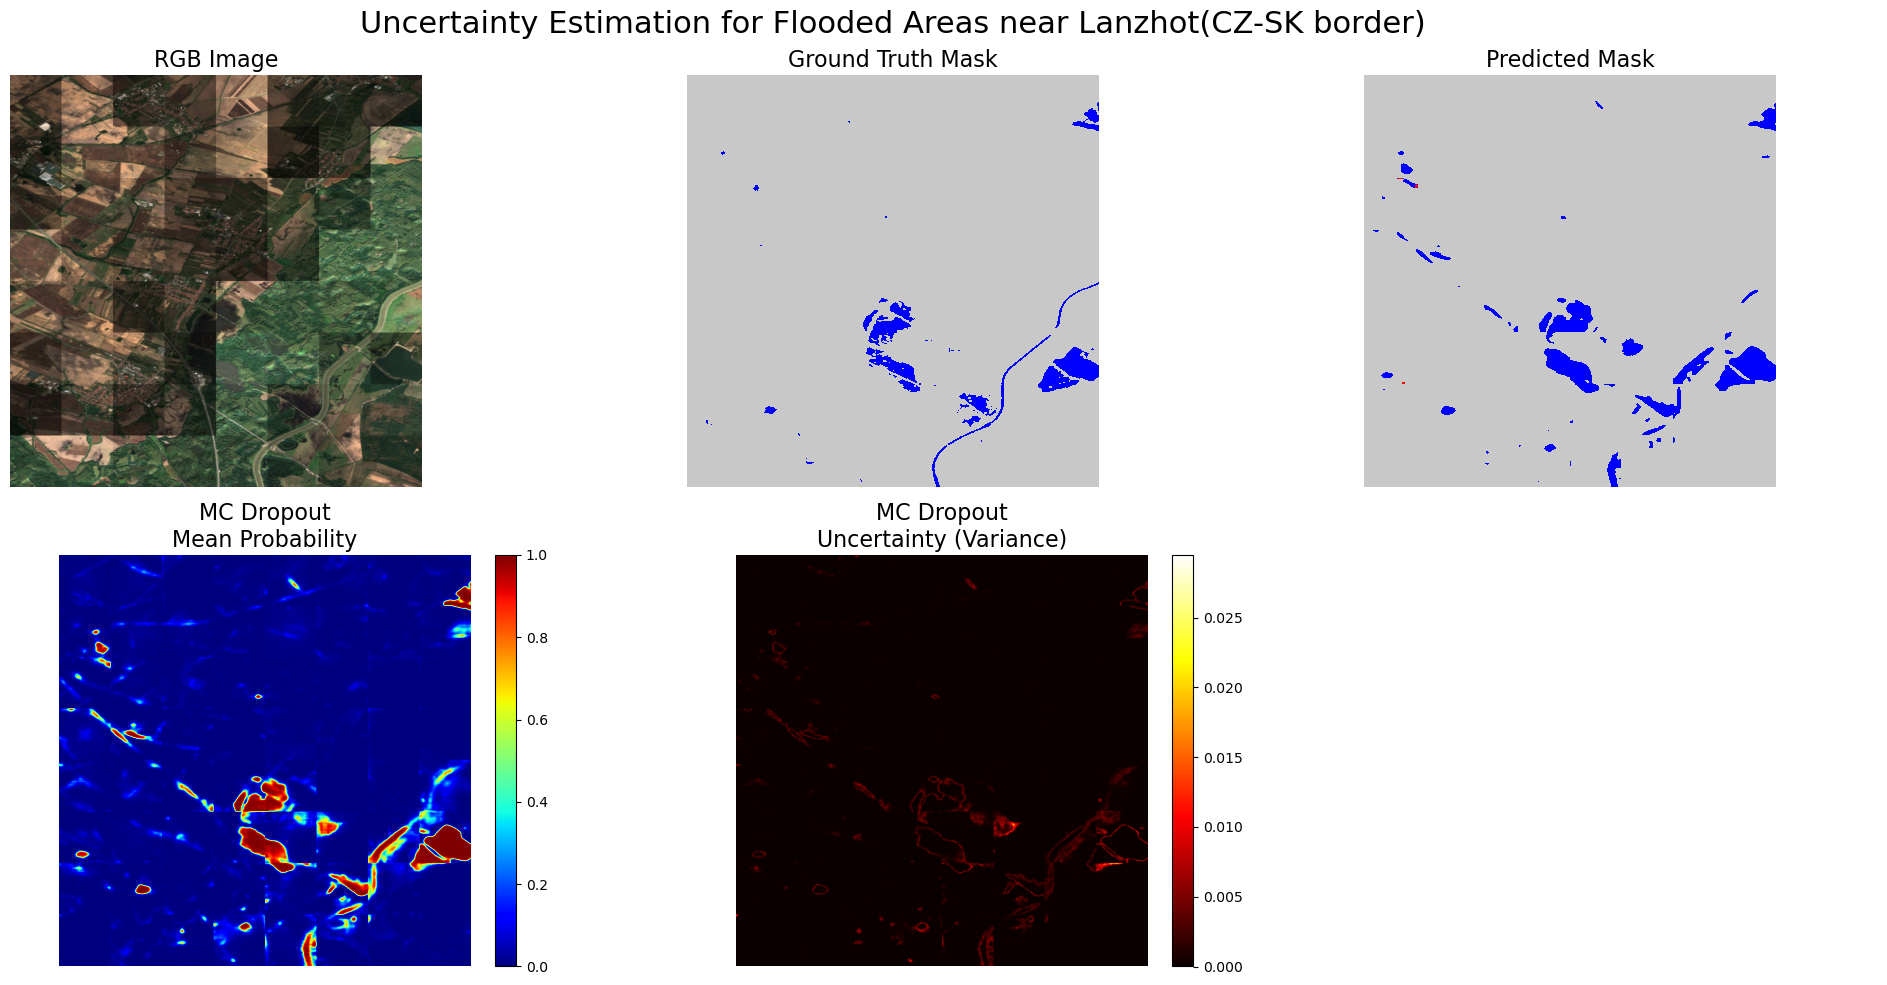

In [24]:
# predictions made by the model

image_dir = "./Data_Boris_additional_v2/flood_upd/4b22394a3e676511e4761523e36406ea"
perm_water_path = "./Permanent_Water/Permanent_Water_Mask2-0000000000-0000000000.tif"

rgb_paths = sorted(glob.glob(os.path.join(image_dir, "rgb_nir_*.tif")))
grid = get_patch_grid(rgb_paths)

stitched_outputs = stitch_with_uncertainty(
    grid=grid,
    model=model4,
    perm_water_path=perm_water_path,
    threshold=0.5,
    device="cuda",
    n_iter=30
)

rgb_stitched, gt_stitched, pred_stitched, mc_mean_stitched, mc_var_stitched = stitched_outputs

visualize_uncertainty_minimal(
    rgb_img=rgb_stitched,
    gt_mask=gt_stitched,
    pred_mask=pred_stitched,
    mc_water_prob=mc_mean_stitched,
    uncertainty_map=mc_var_stitched,
    class_colors=["#c8c8c8", "blue", "red"],
    title="Uncertainty Estimation for Flooded Areas near Lanzhot(CZ-SK border)"
)


mean_prob_map min/max: 7.661109e-09 0.9999916
mean_prob_map dtype: float32
Threshold 0.10 -> confident pixels: 358349 / 4194304
Threshold 0.31 -> confident pixels: 216737 / 4194304
Threshold 0.53 -> confident pixels: 170101 / 4194304
Threshold 0.74 -> confident pixels: 134244 / 4194304
Threshold 0.95 -> confident pixels: 82653 / 4194304


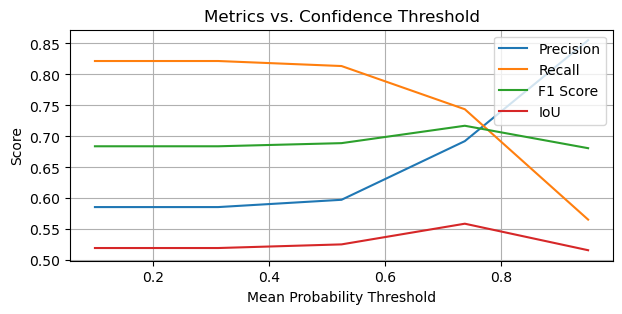

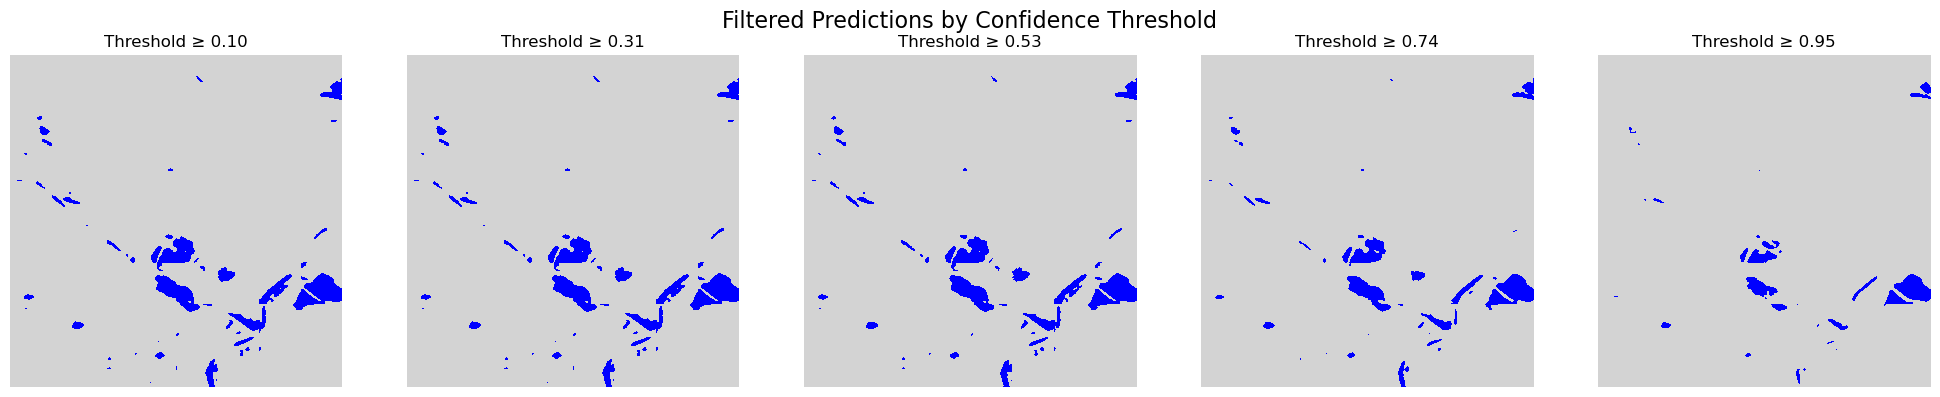

In [25]:
# quality of predictions for different levels of model's confidence

results, filtered_masks = evaluate_fixed_gt_with_confidence_thresholds(
    gt_mask=gt_stitched,
    mean_prob_map=mc_mean_stitched,
    class_prob_map=pred_stitched,  # or MC argmax if available
    thresholds=np.linspace(0.1, 0.95, 5),
    class_of_interest=1,
)

plot_metrics_vs_threshold(results)
plot_prediction_masks_by_threshold(filtered_masks, thresholds=np.linspace(0.1, 0.95, 5))


In [26]:
results

[{'threshold': 0.1,
  'precision': 0.5859455696130295,
  'recall': 0.8217118162538514,
  'f1_score': 0.6840846402920836,
  'iou': 0.5198545903772448,
  'coverage': 0.08543705940246582},
 {'threshold': 0.3125,
  'precision': 0.5859455696130295,
  'recall': 0.8217118162538514,
  'f1_score': 0.6840846402920836,
  'iou': 0.5198545903772448,
  'coverage': 0.05167412757873535},
 {'threshold': 0.525,
  'precision': 0.5977129754835675,
  'recall': 0.813612900644232,
  'f1_score': 0.6891491128471928,
  'iou': 0.5257265487640914,
  'coverage': 0.04055523872375488},
 {'threshold': 0.7374999999999999,
  'precision': 0.692403384881261,
  'recall': 0.7438757952863031,
  'f1_score': 0.7172172732147887,
  'iou': 0.5591104855396757,
  'coverage': 0.032006263732910156},
 {'threshold': 0.95,
  'precision': 0.8552744606971314,
  'recall': 0.5657316633988235,
  'f1_score': 0.6810045855651035,
  'iou': 0.5163054989519198,
  'coverage': 0.019706010818481445}]

#### Example 2: Kisoroszi Village

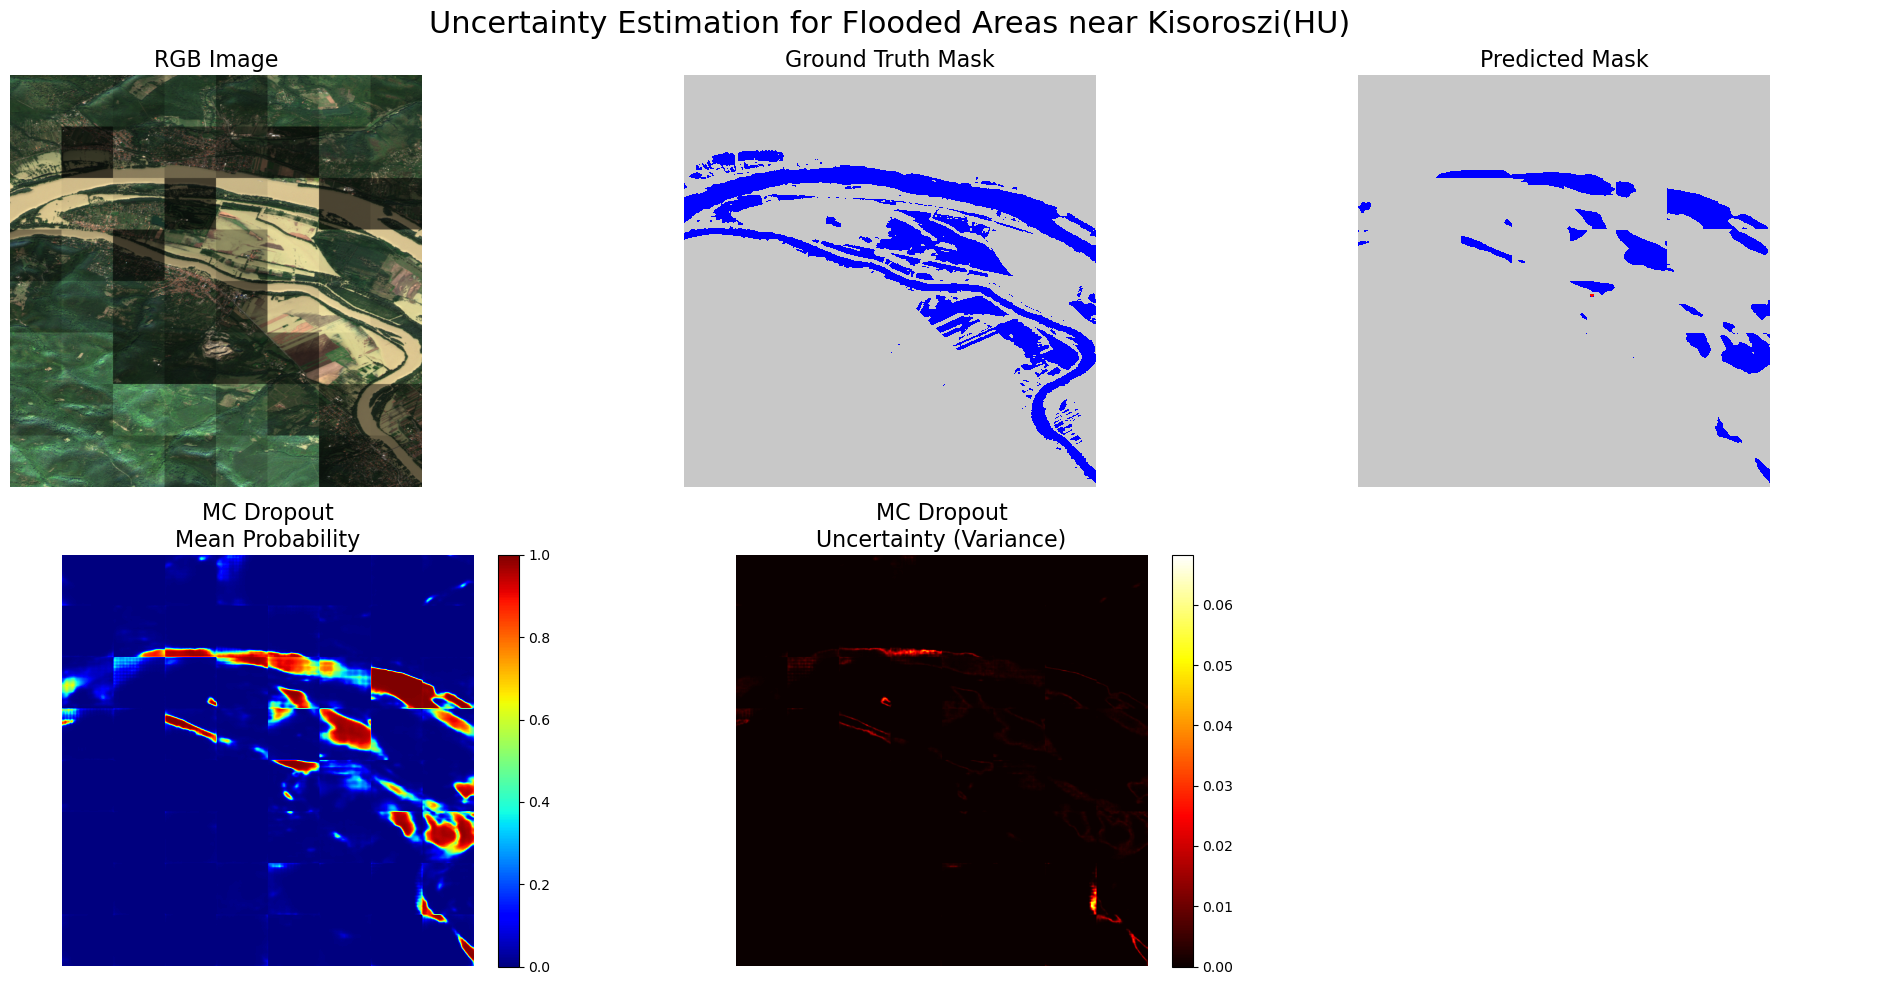

In [27]:
image_dir = "./Data_Boris_additional_v2/flood_upd/6368a40a3901fa1d9f9b63a5e1c9aee4"
perm_water_path = "./Permanent_Water/Permanent_Water_Mask2-0000000000-0000000000.tif"

rgb_paths = sorted(glob.glob(os.path.join(image_dir, "rgb_nir_*.tif")))
grid = get_patch_grid(rgb_paths)

stitched_outputs = stitch_with_uncertainty(
    grid=grid,
    model=model4,
    perm_water_path=perm_water_path,
    threshold=0.5,
    device="cuda",
    n_iter=30
)

rgb_stitched, gt_stitched, pred_stitched, mc_mean_stitched, mc_var_stitched = stitched_outputs

visualize_uncertainty_minimal(
    rgb_img=rgb_stitched,
    gt_mask=gt_stitched,
    pred_mask=pred_stitched,
    mc_water_prob=mc_mean_stitched,
    uncertainty_map=mc_var_stitched,
    class_colors=["#c8c8c8", "blue", "red"],
    title="Uncertainty Estimation for Flooded Areas near Kisoroszi(HU)"
)

mean_prob_map min/max: 3.7662868e-12 0.9998434
mean_prob_map dtype: float32
Threshold 0.10 -> confident pixels: 454410 / 4194304
Threshold 0.31 -> confident pixels: 304872 / 4194304
Threshold 0.53 -> confident pixels: 240828 / 4194304
Threshold 0.74 -> confident pixels: 186696 / 4194304
Threshold 0.95 -> confident pixels: 85958 / 4194304


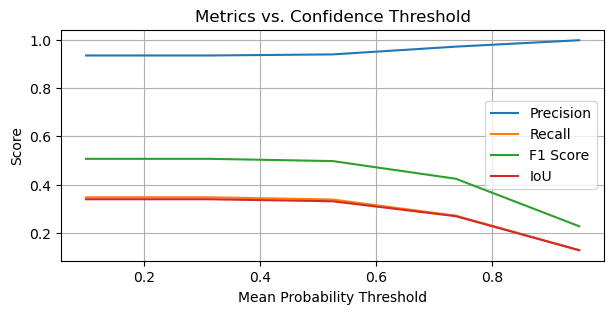

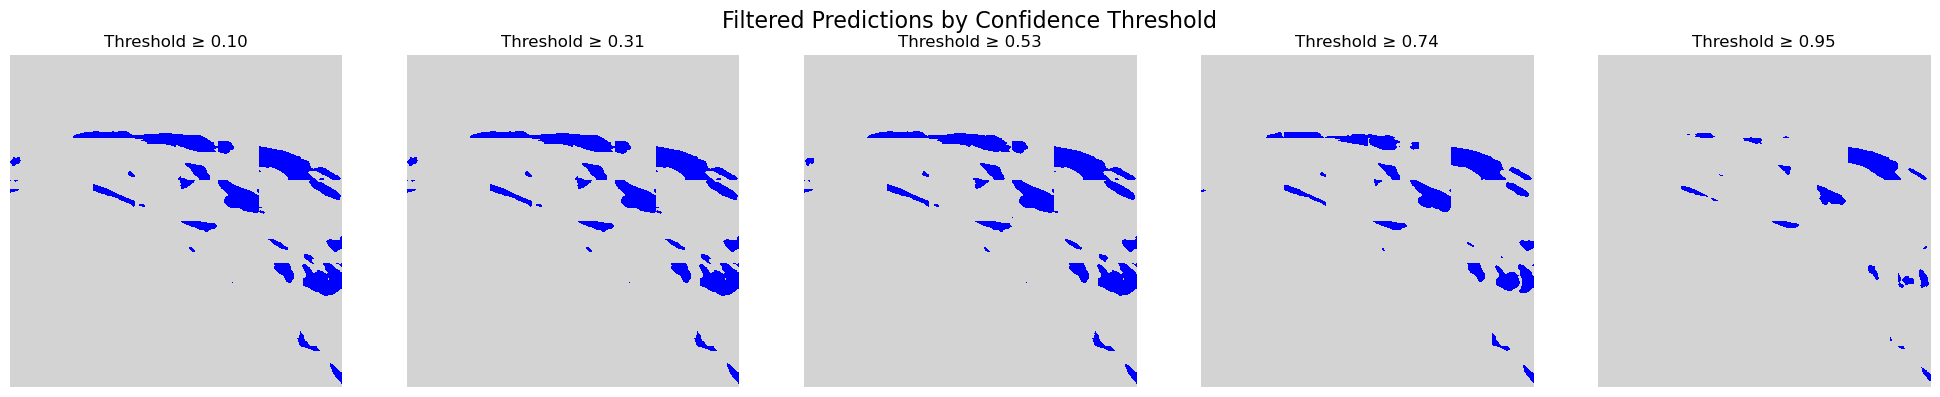

In [28]:
# quality of predictions for different levels of model's confidence

results, filtered_masks = evaluate_fixed_gt_with_confidence_thresholds(
    gt_mask=gt_stitched,
    mean_prob_map=mc_mean_stitched,
    class_prob_map=pred_stitched,  # or MC argmax if available
    thresholds=np.linspace(0.1, 0.95, 5),
    class_of_interest=1,
)

plot_metrics_vs_threshold(results)
plot_prediction_masks_by_threshold(filtered_masks, thresholds=np.linspace(0.1, 0.95, 5))

In [29]:
results

[{'threshold': 0.1,
  'precision': 0.9345245517846152,
  'recall': 0.34753418571358047,
  'f1_score': 0.5066526511376349,
  'iou': 0.33927314467300856,
  'coverage': 0.10833978652954102},
 {'threshold': 0.3125,
  'precision': 0.9345245517846152,
  'recall': 0.34753418571358047,
  'f1_score': 0.5066526511376349,
  'iou': 0.33927314467300856,
  'coverage': 0.07268714904785156},
 {'threshold': 0.525,
  'precision': 0.9389728874511546,
  'recall': 0.3382519473253541,
  'f1_score': 0.49734298773111385,
  'iou': 0.33097572078685317,
  'coverage': 0.057417869567871094},
 {'threshold': 0.7374999999999999,
  'precision': 0.9711563182928397,
  'recall': 0.27122835203992335,
  'f1_score': 0.4240315162825941,
  'iou': 0.2690609112197381,
  'coverage': 0.04451179504394531},
 {'threshold': 0.95,
  'precision': 0.9977081830661486,
  'recall': 0.12829235236304398,
  'f1_score': 0.22735038883196654,
  'iou': 0.1282545560045343,
  'coverage': 0.02049398422241211}]